In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NO Memory Data Analysis

## Card Frequency Data Analysis 

In [5]:
df = pd.read_csv("./Data/no_memory_sim_card_frequency.txt")
df.head().style.set_properties(**{'text-align': 'center'})

,run,card_id,card_frequency
0,0,5,6
1,0,39,2
2,0,36,3
3,0,6,2
4,0,37,2


### Card Frequency Max Value By Run

In [8]:
df_max  = df.groupby('run')['card_frequency'].max().reset_index()

df_max.head().style.set_properties(**{'text-align': 'center'})

,run,card_frequency
0,0,6
1,1,6
2,2,5
3,3,8
4,4,5


In [10]:
std = df_max['card_frequency'].std()
print("STD Max Card Frequency:",round(std,3))

STD Max Card Frequency: 0.904


In [12]:
mean = df_max['card_frequency'].mean()
print("Mean Max Card Frequency:",mean)

Mean Max Card Frequency: 6.03


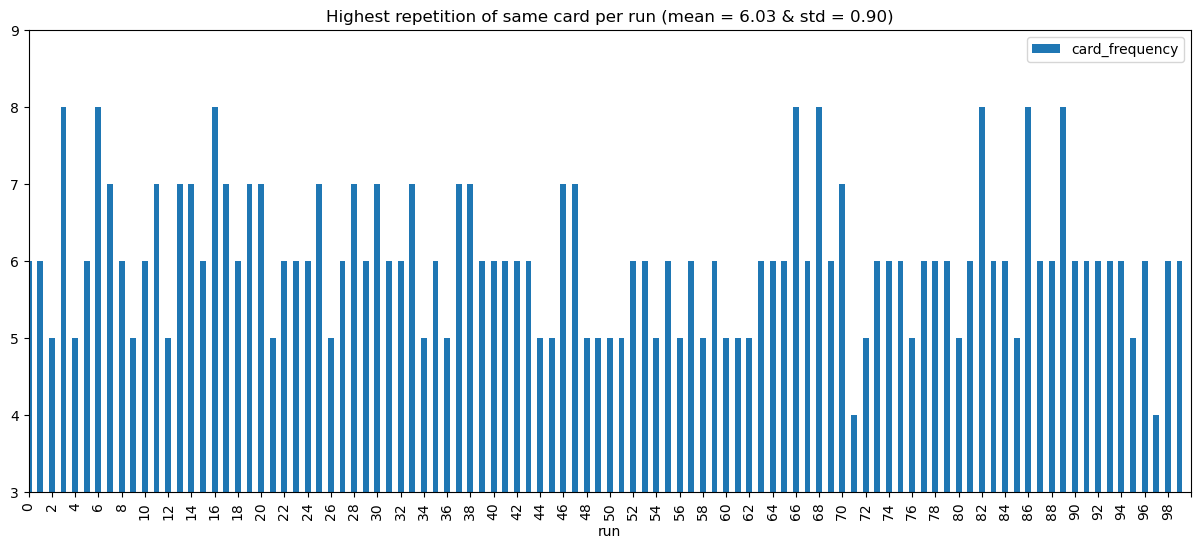

In [14]:
ax = df_max.plot(
    kind='bar', 
    x='run', 
    y='card_frequency', 
    figsize=(15, 6), 
    title=(f"Highest repetition of same card per run (mean = {mean:.2f} & std = {std:.2f})")
)
plt.xlim(0,100)
plt.ylim(3,9)

plt.xticks(np.arange(0, 101, step = 2)) # Marcas no X de 10 em 10
plt.yticks(np.arange(3, 10, step = 1))

plt.show()

### Frequency of Max Values

In [17]:
df_max_counts = df_max['card_frequency'].value_counts().reset_index()
df_max_counts.columns = ['max_repetition', 'frequency'] #rename
df_max_counts = df_max_counts.sort_values(by='max_repetition')

df_max_counts.head()

,max_repetition,frequency
4,4,2
1,5,25
0,6,49
2,7,16
3,8,8


### Mean Frequencies by Run 

1 - groupby('run'): Ele junta todos os dados do Run 1, depois todos do Run 2, etc.
['card_frequency'].

2 - mean(): Ele soma todas as frequências das cartas que apareceram no Run 1 e divide pelo número de cartas diferentes que saíram nesse run.

3 - Resultado: Vais ter 100 linhas (uma por run). Se o Run 1 der 2.5, significa que, em média, as cartas que saíram nesse run apareceram 2.5 vezes cada uma.

In [20]:
df_mean  = df.groupby('run')['card_frequency'].mean().reset_index()
print(df_mean.round(2).head())

   run  card_frequency
0    0            2.44
1    1            2.70
2    2            2.56
3    3            2.50
4    4            2.44


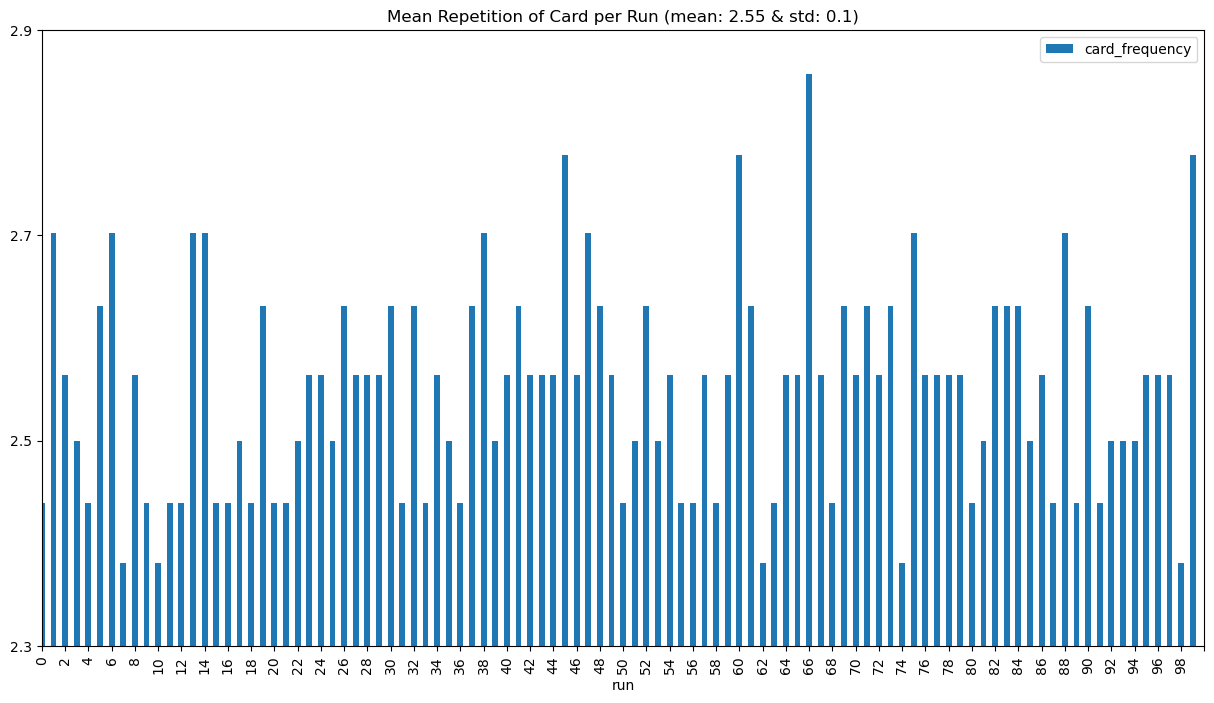

In [26]:
ax = df_mean.plot(
    kind='bar', 
    x='run', 
    y='card_frequency', 
    figsize=(15, 8), 
    title=f"Mean Repetition of Card per Run (mean: {round(df_mean['card_frequency'].mean(),2)} & std: {round(df_mean['card_frequency'].std(),2)})"   
)

plt.xlim(0,99)
plt.ylim(2.3,2.9)

plt.xticks(np.arange(0, 101, step = 2))
plt.yticks(np.arange(2.3, 3, step = 0.2))

plt.show()

### Frequency of cards

In [418]:
df_mean_counts = df_mean['card_frequency'].value_counts().reset_index()
df_mean_counts.columns = ['mean_repetition', 'frequency'] #rename

print(df_mean_counts.round(2).head())

   mean_repetition  frequency
0             2.56         30
1             2.44         23
2             2.63         17
3             2.50         13
4             2.70          8


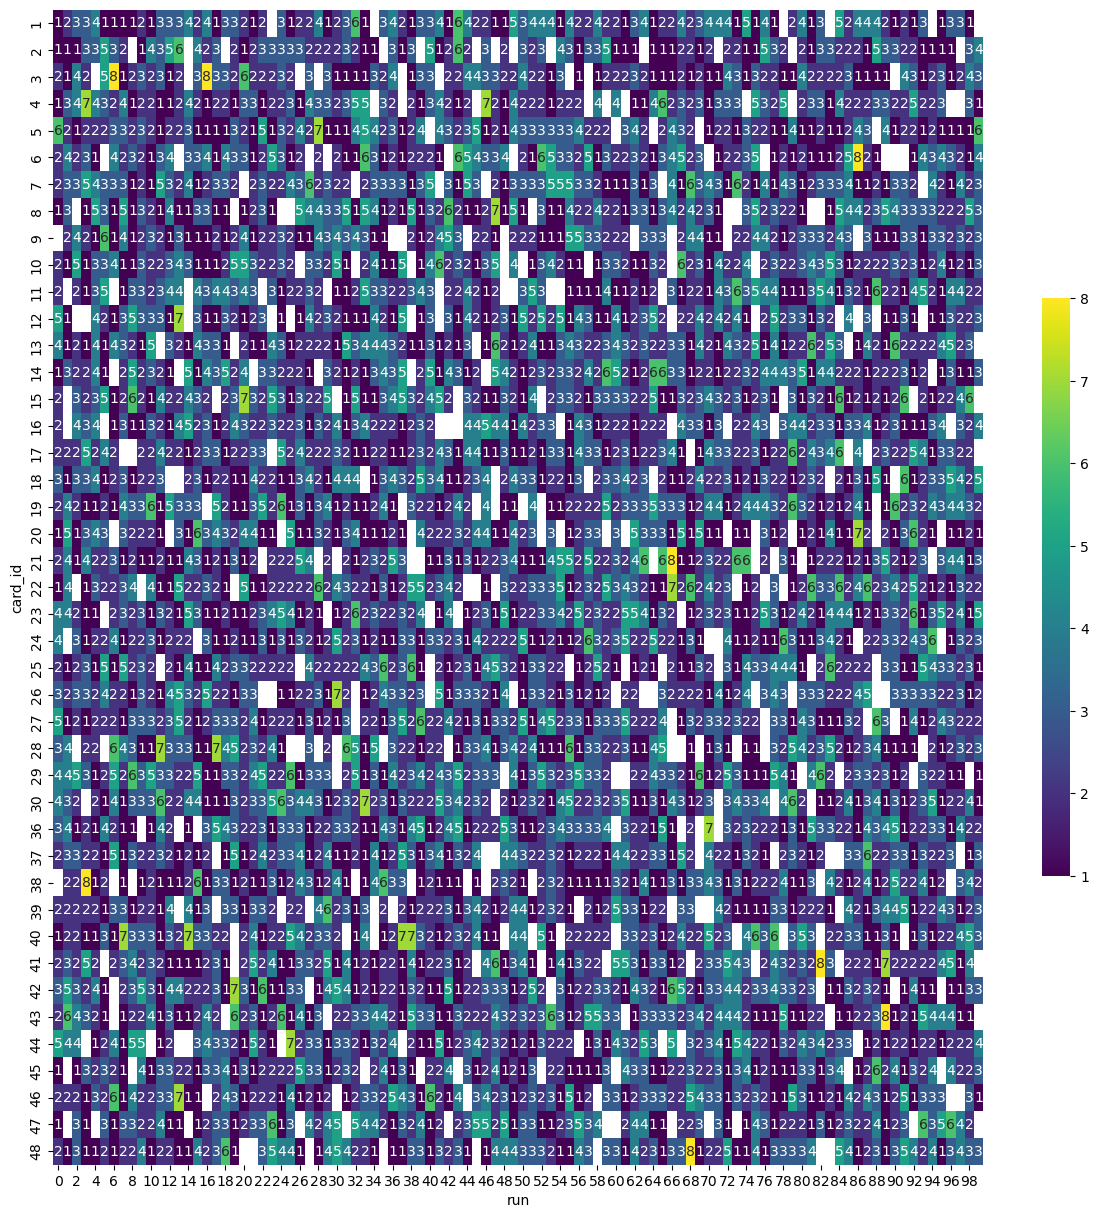

In [116]:
plt.figure(figsize=(15,15))

result = df.pivot(index='card_id', columns='run', values='card_frequency')
sns.heatmap(result, annot=True, fmt="g", cmap='viridis',cbar_kws={"shrink": 0.5},)

plt.show()

### Amount of Times a Card is Displayed in 100 Runs

In [30]:
df_total_card_count =  df.groupby('card_id')['card_frequency'].sum().reset_index()
df_total_card_count.columns = ['card_id', 'card_count'] #rename

df_total_card_count.head()
df_total_card_count.tail()

,card_id,card_count
38,44,233
39,45,208
40,46,236
41,47,232
42,48,241


In [32]:
std = df_total_card_count['card_count'].std()
mean = df_total_card_count['card_count'].mean()

print("STD  Card Count:",round(std,3))
print("Mean Card Count:",round(mean,3))

STD  Card Count: 14.72
Mean Card Count: 232.558


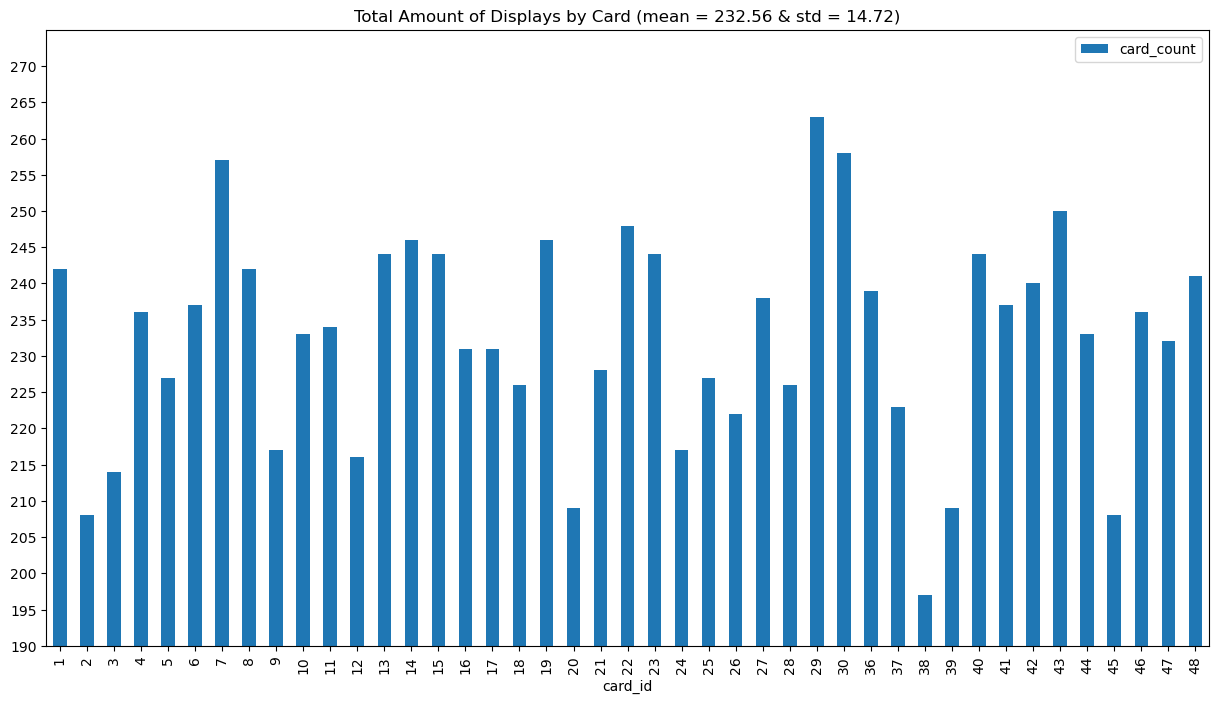

In [34]:
ax = df_total_card_count.plot(
    kind='bar', 
    x='card_id', 
    y='card_count', 
    figsize=(15, 8), 
    title=(f"Total Amount of Displays by Card (mean = {mean:.2f} & std = {std:.2f})")
)

plt.ylim(190,275)
#plt.xlim(0,48)

#plt.xticks(np.arange(0, 48, step = 1))
plt.yticks(np.arange(190, 275, step = 5))

plt.show()

### Average Card Display Times

In [70]:
df_total_card_count =  df.groupby('card_id')['card_frequency'].sum().reset_index()
df_total_card_count.columns = ['card_id', 'card_count'] #rename
df_average_card_count = df_total_card_count
df_average_card_count["card_count_real_mean"] = df_total_card_count["card_count"]/100 #média real != mean(média das runs em que aparece)

print(df_average_card_count.head())


   card_id  card_count  card_count_real_mean
0        1         242                  2.42
1        2         208                  2.08
2        3         214                  2.14
3        4         236                  2.36
4        5         227                  2.27


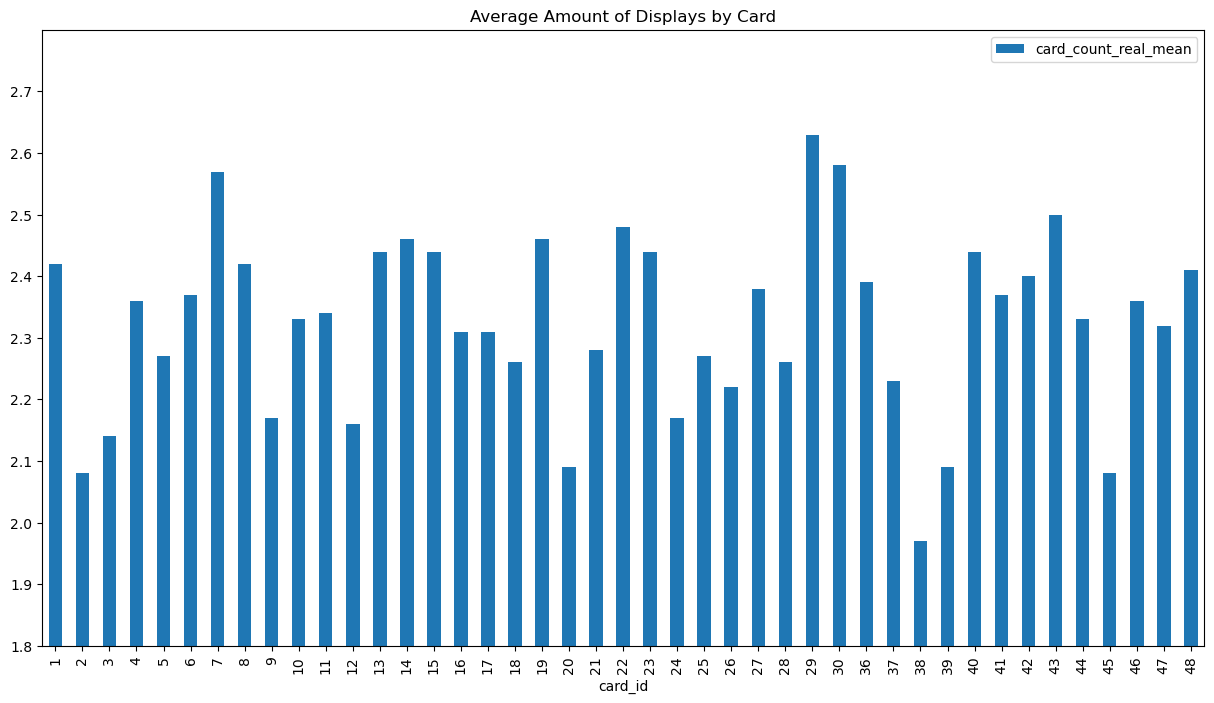

In [74]:
ax = df_average_card_count.plot(
    kind='bar', 
    x ='card_id', 
    y ='card_count_real_mean', 
    figsize = (15, 8), 
    title = "Average Amount of Displays by Card"   
)
plt.ylim(1.8,2.8)
plt.yticks(np.arange(1.8, 2.8, step = 0.1))

plt.show()

### Mean Card Display Times and Presence %
Nota: mean() só conta com as entradas que existem, logo é = ou menor que / 100 (númeruo total de runs)

Imagina uma carta que aparece 100 vezes no total (em 100 runs):

**Cenário A (Perfeitamente Espalhada)**: Aparece 1x em cada um dos 100 runs.
Global: 1.0
Intensidade: 1.0
Resultado: Os dois gráficos são iguais.

**Cenário B (Muito Concentrada)**: Aparece 100 vezes num único run e 0 nos restantes.
Global: 1.0 (100 / 100)
Intensidade: 100.0 (100 / 1 run onde apareceu)
Resultado: A barra da Intensidade será gigante comparada com a Global.

**Cenário C (Média)**: Aparece 50 vezes em 2 runs.
Global: 1.0 (100 / 100)
Intensidade: 50.0 (100 / 2 runs onde apareceu)

**Conclusão**: Quanto maior for a diferença entre a Intensidade e a Global, mais a carta tende a aparecer em "surtos" ou amontoados num único run em vez de estar distribuída.

In [42]:
# 1. MÉDIA GLOBAL (Média de 'presença' em 100 runs)
# Se der 1.0, significa que em média vês 1 carta destas por run (total de 100 em 100 runs)
mean_global = df.groupby('card_id')['card_frequency'].sum() / 100

# 2. MÉDIA DE INTENSIDADE (Média de 'amontoado' quando aparece)
# Se a carta aparece 100 vezes num só run e 0 nos outros 99, este valor será 100!
mean_intensity = df.groupby('card_id')['card_frequency'].mean()

# 3 Em quantos runs (dos 100) a carta apareceu?
presence_count = df.groupby('card_id')['run'].nunique()
presence_percentage = (presence_count / 100) * 100

# Criar o DF para comparar
df_compare = pd.DataFrame({
    'Presence (%)': presence_percentage,
    'Global (Espalhado)': mean_global,
    'Intensidade (Concentrado)': mean_intensity
    
})
print(df_compare.round(2).head())


         Presence (%)  Global (Espalhado)  Intensidade (Concentrado)
card_id                                                             
1                94.0                2.42                       2.57
2                87.0                2.08                       2.39
3                91.0                2.14                       2.35
4                90.0                2.36                       2.62
5                95.0                2.27                       2.39


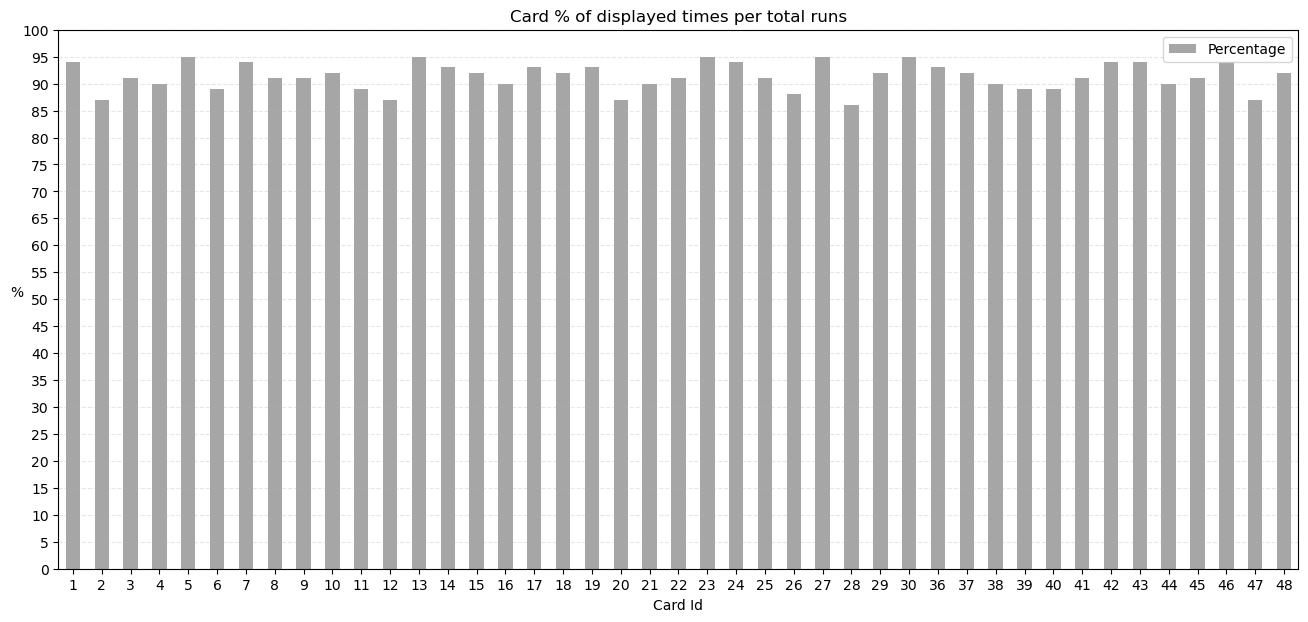

In [50]:
mean_intensity = mean_intensity.reindex(mean_global.index)

plt.figure(figsize=(16, 7))

# 2. Desenha as barras e guarda o objeto 'ax'
ax = presence_percentage.plot(kind = 'bar', color='black', alpha=.35, label='Percentage')

plt.title("Card % of displayed times per total runs")
#plt.ylim(0,3)
plt.yticks(np.arange(0, 101, step = 5))

plt.xticks(range(len(mean_global)), mean_global.index, rotation=0)
plt.xlabel("Card Id")
plt.ylabel("%", rotation=0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


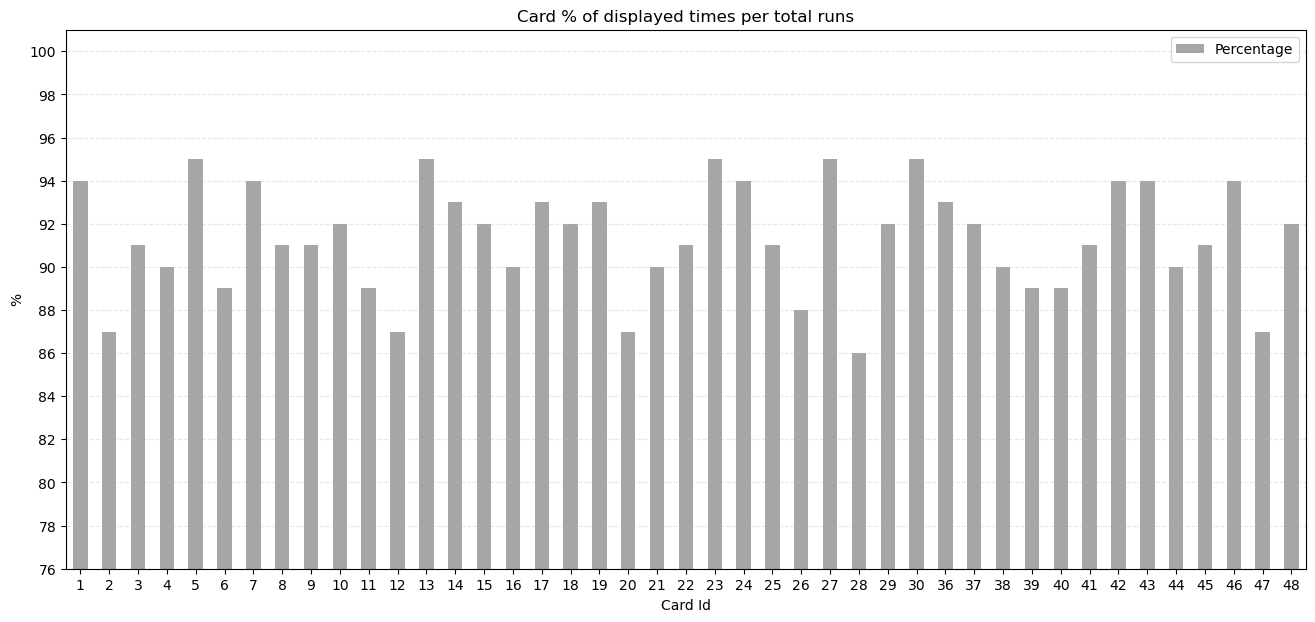

In [48]:
mean_intensity = mean_intensity.reindex(mean_global.index)

plt.figure(figsize=(16, 7))

# 2. Desenha as barras e guarda o objeto 'ax'
ax = presence_percentage.plot(kind = 'bar', color='black', alpha=.35, label='Percentage')

plt.title("Card % of displayed times per total runs")
plt.ylim(76,101)
plt.yticks(np.arange(76, 101, step = 2))

plt.xticks(range(len(mean_global)), mean_global.index, rotation=0)
plt.xlabel("Card Id")
plt.ylabel("%")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


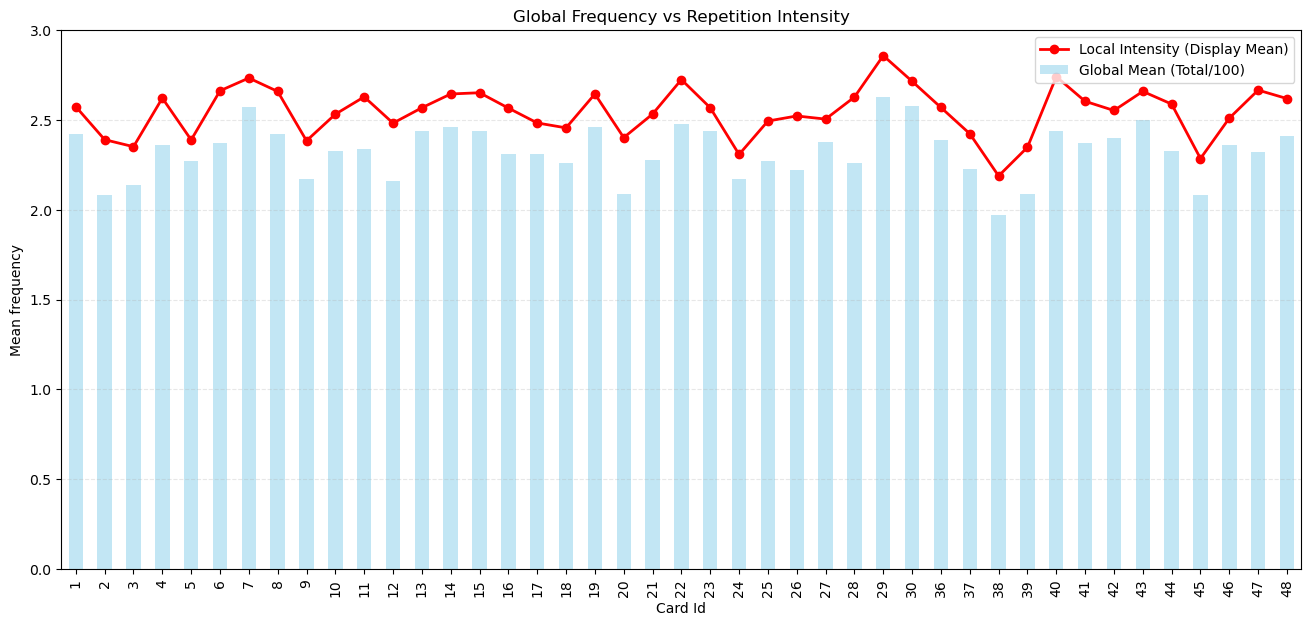

In [78]:
# 1. Garante que ambos têm exatamente os mesmos IDs (o reindex resolve o "salto")
mean_intensity = mean_intensity.reindex(mean_global.index)

plt.figure(figsize=(16, 7))

# 2. Desenha as barras e guarda o objeto 'ax'
ax = mean_global.plot(kind='bar', color='skyblue', alpha=0.5, label='Global Mean (Total/100)')

# 3. TRUQUE: Usa os números das posições (0, 1, 2...) para a linha bater certo com as barras
plt.plot(range(len(mean_intensity)), mean_intensity.values, 
         marker='o', color='red', label='Local Intensity (Display Mean)', linewidth=2)

plt.title("Global Frequency vs Repetition Intensity")
plt.xticks(range(len(mean_global)), mean_global.index, rotation=90)
plt.xlabel("Card Id")
plt.ylabel("Mean frequency")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


## Run Summary Data Analysis

In [6]:
df1_original = pd.read_csv("./Data/no_memory_sim_summary.txt", index_col=0)

### Mean Values & Standart Deviation

In [9]:
df1 = pd.read_csv("./Data/no_memory_sim_summary.txt")
df1.head()

,run,unique_cards,repetitions,final_wealth,final_morale,final_stability,final_progress
0,0,41,59,-205,250,10,465
1,1,37,63,-235,300,135,315
2,2,39,61,-185,400,-60,380
3,3,40,60,-360,375,-30,335
4,4,41,59,-150,280,20,385


In [11]:
df1_mean_wv = df1.drop(['run', 'repetitions'], axis = 1).mean()
df1_mean_wv['Std'] = df1['unique_cards'].std()
df1_mean_wv = df1_mean_wv.loc[['unique_cards','Std','final_wealth','final_morale', 'final_stability','final_progress']] 

In [13]:
print(df1_mean_wv.round(2))

unique_cards        39.28
Std                  1.54
final_wealth      -155.40
final_morale       302.60
final_stability    -10.10
final_progress     369.70
dtype: float64


### Absolute Card  Variance

In [16]:
unique_card_mean = df1['unique_cards'].mean()
df1['Mean Dev'] = df1['unique_cards'] - unique_card_mean

col_deviation = df1.pop('Mean Dev')
df1.insert(2, 'Mean Dev', col_deviation)

df1 = df1.drop(['run', 'repetitions'], axis = 1)

In [18]:
df1.head().style.set_properties(**{'text-align': 'center'}).format(precision=2)

,unique_cards,Mean Dev,final_wealth,final_morale,final_stability,final_progress
0,41,1.72,-205,250,10,465
1,37,-2.28,-235,300,135,315
2,39,-0.28,-185,400,-60,380
3,40,0.72,-360,375,-30,335
4,41,1.72,-150,280,20,385


### Absolute World Values Variance

In [57]:
wealth_mean = df1['final_wealth'].mean()
moral_mean = df1['final_morale'].mean()
stability_mean = df1['final_stability'].mean()
progress_mean = df1['final_progress'].mean()

# Usamos .abs() se quiseres apenas a distância, ou deixamos sem se quiseres valores positivos/negativos
df1['wlt_dv'] = df1['final_wealth'] - wealth_mean
df1['moral_dv'] = df1['final_morale'] - moral_mean
df1['stab_dv'] = df1['final_stability'] - stability_mean
df1['prog_dv'] = df1['final_progress'] - progress_mean

In [59]:
df1 = df1[['unique_cards','Mean Dev','final_wealth','wlt_dv','final_morale','moral_dv','final_stability', 'stab_dv','final_progress','prog_dv']]

In [61]:
print(f"Means: Wealth: {wealth_mean:.2f} | Moral: {moral_mean:.2f} | Stability: {stability_mean:.2f} | Progress: {progress_mean:.2f}") 

Means: Wealth: -155.40 | Moral: 302.60 | Stability: -10.10 | Progress: 369.70


In [63]:
df1.head().style.set_properties(**{'text-align': 'center'}).format(precision=2)

,unique_cards,Mean Dev,final_wealth,wlt_dv,final_morale,moral_dv,final_stability,stab_dv,final_progress,prog_dv
0,41,1.72,-205,-49.60,250,-52.60,10,20.10,465,95.30
1,37,-2.28,-235,-79.60,300,-2.60,135,145.10,315,-54.70
2,39,-0.28,-185,-29.60,400,97.40,-60,-49.90,380,10.30
3,40,0.72,-360,-204.60,375,72.40,-30,-19.90,335,-34.70
4,41,1.72,-150,5.40,280,-22.60,20,30.10,385,15.30


### World Variables Standart Deviation Graph
Aqui comparamos a volatilidade das métricas finais. No sistema com memória, esperamos que estas barras sejam mais baixas, indicando um jogo mais equilibrado.


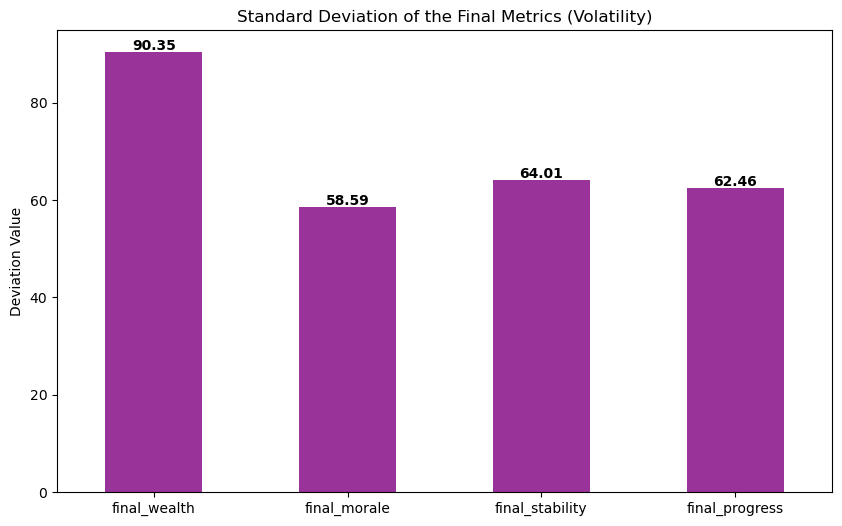

In [23]:
# Selecionar as colunas de métricas do Ficheiro 3 (Sumário)
metricas = ['final_wealth', 'final_morale', 'final_stability', 'final_progress']
std_values = df1[metricas].std()

# Plot
std_values.plot(kind='bar', figsize=(10, 6), color='purple', alpha=0.8)
plt.title("Standard Deviation of the Final Metrics (Volatility)")
plt.ylabel("Deviation Value")
plt.xticks(rotation=0)

# Adicionar os valores por cima das barras para leitura fácil
for i, v in enumerate(std_values):
    plt.text(i, v + 0.5, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()


### Graphs Card Variation to mean

In [21]:
std = df1_original['unique_cards'].std()
print("STD Unique Cards:",round(std,2))

STD Unique Cards: 1.54


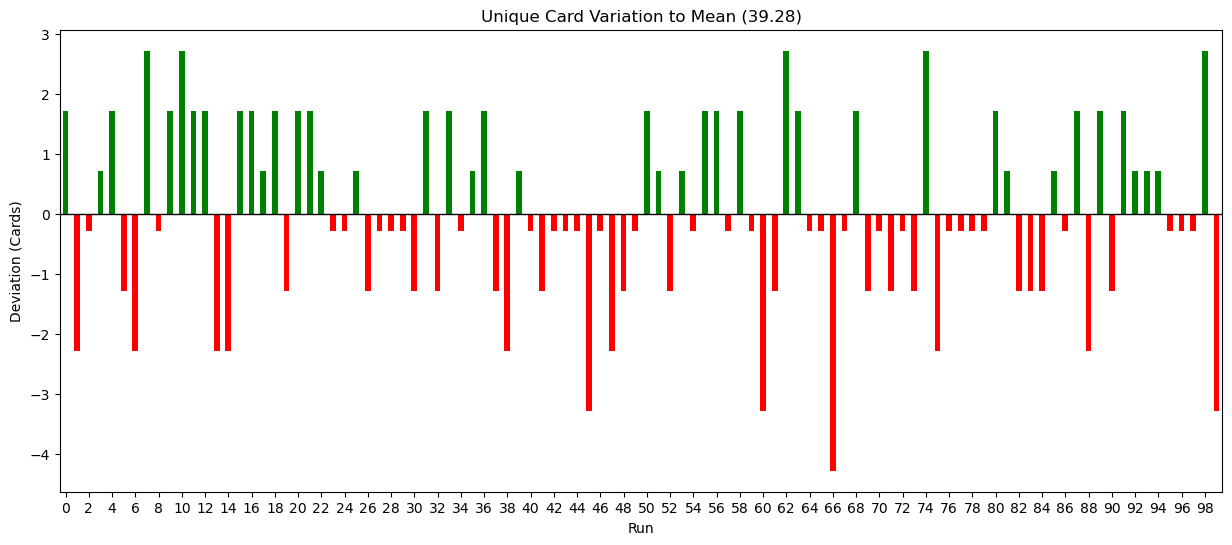

In [421]:
# 1. Calcular o desvio (como fizemos antes)
media = df1['unique_cards'].mean()
df1['Desvio'] = df1['unique_cards'] - media
# 2. Definir as cores com base no valor (Positivo = Verde, Negativo = Vermelho)
cores = ['green' if x > 0 else 'red' for x in df1['Desvio']]

# 3. Criar o gráfico
plt.figure(figsize=(15, 6))
df1['Desvio'].plot(kind='bar', color=cores)

plt.xticks(np.arange(0, 100, step = 2))
plt.xticks(rotation = 0)

plt.axhline(0, color='black', linewidth=1) # Linha do zero (a média)
plt.title(f"Unique Card Variation to Mean ({media:.2f})")
plt.xlabel("Run")
plt.ylabel("Deviation (Cards)")
plt.show()

## Logs Analysis

### Card Exhaustion Graph

In [6]:
df_logs = pd.read_csv("./Data/no_memory_sim_log.txt", index_col=0)

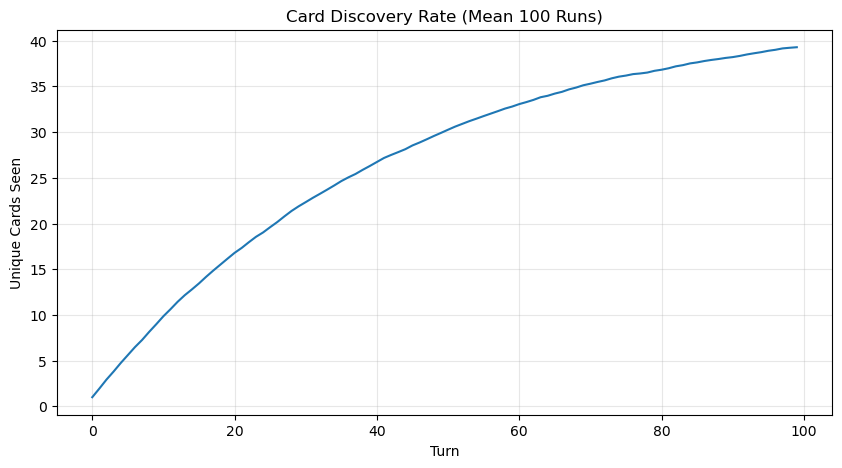

In [84]:
df_newcard_rate = df_logs
# 1. Criar uma coluna que marca se a carta é nova naquele run
df_newcard_rate['is_new'] = df_newcard_rate.groupby('run')['card_id'].transform(lambda x: ~x.duplicated())

# 2. Somar cumulativamente as cartas novas por run
df_newcard_rate['cards_discovered'] = df_newcard_rate.groupby('run')['is_new'].cumsum()

# 3. Tirar a média de descoberta de todos os runs por turno
df_newcard_rate = df_newcard_rate.groupby('turn')['cards_discovered'].mean()

# Plot
df_newcard_rate.plot(figsize=(10, 5), title="Card Discovery Rate (Mean 100 Runs)")
plt.xlabel("Turn")
plt.ylabel("Unique Cards Seen")
plt.grid(True, alpha=0.3)
plt.show()


### Recurrence Index (Distância entre a mesma carta)
Este código calcula quantos turnos passaram desde a última vez que a mesma carta apareceu.
Num sistema com memória, este número deve ser sempre alto. No simples, verás muitos "1" ou "2" (cartas a repetir quase logo a seguir).

Distância média entre a mesma carta: 23.02 turnos
Mínima distância registada: 1.0 turnos


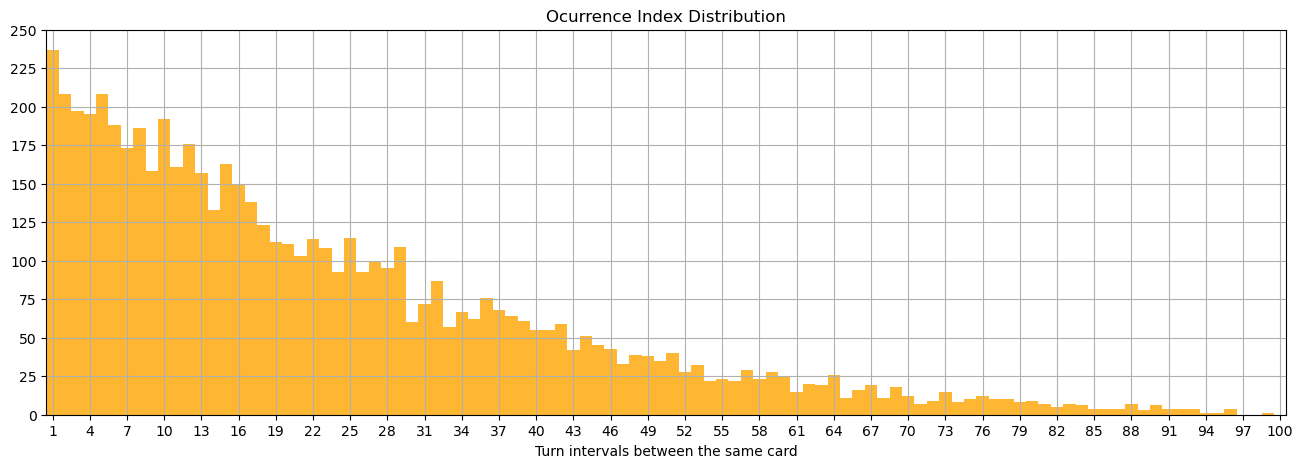

In [42]:
df_recurrence = df_logs

# Calcular a distância (diff) entre turnos para o mesmo card_id dentro de cada run
df_recurrence = df_recurrence.sort_values(['run', 'turn'])
df_recurrence['distancia_recorrencia'] = df_recurrence.groupby(['run', 'card_id'])['turn'].diff()

# Filtrar NaN (primeira aparição não tem distância)
df_recurrence = df_recurrence['distancia_recorrencia'].dropna()

print(f"Distância média entre a mesma carta: {df_recurrence.mean():.2f} turnos")
print(f"Mínima distância registada: {df_recurrence.min()} turnos")

plt.figure(figsize=(16, 5))
bins_inteiros = np.arange(0.5, 101.5, 1)
df_recurrence.hist(bins = bins_inteiros, color = 'orange', alpha=0.8, edgecolor='none')

# Força os ticks do X a baterem certo com as barras
plt.xlim(0.5, 100.5)

plt.title("Ocurrence Index Distribution")#Distribuição do Índice de Recorrência")
plt.xlabel("Turn intervals between the same card")# Turnos de intervalo entre a mesma carta")
plt.xticks(np.arange(1, 101, step = 3))
plt.yticks(np.arange(0, 275, step = 25))

plt.show()
